In [1]:
import json
import os
from pathlib import Path
import pandas as pd
import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


### Frame select entries

In [ ]:
def extract_text_from_qa_frame_select(json_path):
    """
    Extract text content from message_list for all roles in the JSON data.
    
    Args:
        json_data: Dictionary containing the parsed JSON data
        
    Returns:
        List of dictionaries with role and text content
    """
    with open(json_path, 'r') as f:
        json_data = json.load(f)

    text_content = {"prompt": "", "subtask_target": "", "keyframe_1": ""}
    
    if 'message_list' in json_data:
        for message in json_data['message_list']:
            role = message.get('role')
            content_list = message.get('content')
            if role == 'system':
                text_content["prompt"] += content_list[0]['text'] + '\n\n'
            elif role == 'user':
                text_content["prompt"] += content_list[0]['text'] + '\n\n'
                if 'video' in content_list[1]:
                    text_content["keyframe_1"] = content_list[1]['video'][-1] # TODO: just picking one to test for now
            elif role == 'assistant':
                text_content["subtask_target"] = "\n\n<tool_call>{\"name\": \"select_frames\", \"arguments\": {\"target_frames\": [1]}}</tool_call>" # TODO: hardcoded because only providing one frame for now, always picking that frame as useful
                break
    
    return text_content

example_json_path = "/iris/u/jrpan/robo_memory/datasets/split_keyframes_subsample_5_retry_05_new_fs_prompt_new_golden_frames_image_aug/2025-07-03__Fri_Jul__4_00_25_17_2025_keyframes/qa_data/qa_frame_select_059.json"

extracted_messages = extract_text_from_qa_frame_select(example_json_path)
df = pd.DataFrame([extracted_messages])
df

,prompt,subtask_target,keyframe_1
0,You are a helpful assistant trying to instruct...,"\n\n<tool_call>{""name"": ""select_frames"", ""argu...",/iris/u/jrpan/robo_memory/datasets/split_keyfr...


### Primitive prediction entries

In [3]:
import cv2

RECENT_FRAMES_NUM = 6 
KEYFRAME_NUM = 2    

def extract_text_from_qa_primitive_prediction(json_path):
    with open(json_path, 'r') as f:
        json_data = json.load(f)

    text_content = {"prompt": ""}
    
    if 'message_list' in json_data:
        for message in json_data['message_list']:
            role = message.get('role')
            content_list = message.get('content')
            for content in content_list:
                if 'text' in content and (role == 'user' or role == 'system'):
                    # text_content["prompt"] += content['text'] + '\n\n'
                    text_content["prompt"] = TEMP_REPLACEMENT_PROMPT
                elif 'video' in content and role == 'user':
                    video_frames = content['video']
                    # Take up to the last 10 frames
                    last_frames = video_frames[-RECENT_FRAMES_NUM:]
                    for i, frame_path in enumerate(last_frames, 1):
                        text_content[f"recent_frame_{i}_path"] = frame_path
                elif 'image' in content and role == 'user':
                    keyframe_index = 1
                    while f"keyframe_{keyframe_index}_path" in text_content and keyframe_index <= KEYFRAME_NUM:
                        keyframe_index += 1
                    # Take up to the first 6 keyframes
                    if keyframe_index <= KEYFRAME_NUM:
                        text_content[f"keyframe_{keyframe_index}_path"] = content['image']
                elif 'text' in content and role == 'assistant':
                    text_content["subtask_target"] = content['text']
                    break
            
    
    return text_content

def load_images_from_paths(extracted_messages, image_keys):
    """
    Load images from file paths and convert them to numpy arrays.
    
    Args:
        extracted_messages: Dictionary containing image file paths
        image_keys: List of keys in extracted_messages that contain image file paths (format: keyframe_*_path, recent_frame_*_path)
        
    Returns:
        Dictionary with image arrays instead of file paths
    """
    for key in image_keys:
        if key in extracted_messages:
            image_path = extracted_messages[key]
            image = Image.open(image_path).convert('RGB')
            image_array = np.array(image)
            
            frame = image_array.copy()
            
            if key.startswith('keyframe_'):
                keyframe_num = key.replace('keyframe_', '').replace('_path', '')
                caption = f"Keyframe {keyframe_num}"
            elif key.startswith('recent_frame_'):
                frame_num = key.replace('recent_frame_', '').replace('_path', '')
                caption = f"Recent Frame {frame_num}"
            else:
                caption = "Frame"
            
            caption_height = 20
            
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.3
            font_thickness = 1
            text_color = (255, 255, 255)  
            
            text_size = cv2.getTextSize(caption, font, font_scale, font_thickness)[0]
            rect_width = min(text_size[0] + 10, frame.shape[1] // 2)  # Add padding, don't exceed half frame width
            
            # Create a black rectangle in the upper left corner
            frame[:caption_height, :rect_width] = 0
            # Position text in top left corner with small padding
            text_x = 5
            text_y = caption_height // 2 + text_size[1] // 2
            
            cv2.putText(frame, caption, (text_x, text_y), font, font_scale, text_color, font_thickness)
            
            new_key = key.replace("_path", "")
            extracted_messages[new_key] = frame
    
    return extracted_messages

def process_single_file(json_file):
    try:
        extracted_messages = extract_text_from_qa_primitive_prediction(json_file)
        # Pass all keys that match the keyframe_*_path and recent_frame_*_path pattern
        image_keys = [key for key in extracted_messages.keys() if key.endswith('_path') and (key.startswith('keyframe_') or key.startswith('recent_frame_'))]
        extracted_messages = load_images_from_paths(extracted_messages, image_keys)
        return extracted_messages
    except Exception as e:
        print(f"Error processing {os.path.basename(json_file)}: {e}")
        return None

TEMP_REPLACEMENT_PROMPT = """You are looking through an egocentric camera attached to the end-effector of a single arm manipulator. There are objects inside the white and black bins. After looking at what objects are in each bin, the objects will appear on the table. You need to carefully observe and remember which specific objects were originally in each bin so that you can now sort the objects back into their correct bins. You have access to the following action primitives to control the robot:
- "look inside the <color> bin"
- "pick up the the <object_name> and put it in the <color> bin"
where <color> is one of {"black", "white"} and <object_name> is one of {"red block", "blue block", "fried chicken", "purple marker", "green tape"}.

The first 6 images are selected frames of particular importance from all the actions the robot has executed so far, to assist in remembering which objects belong in which bins. The last 10 images are the most recent actions the robot has executed. Based on these, output the primitive that the robot should execute right now and nothing else."""

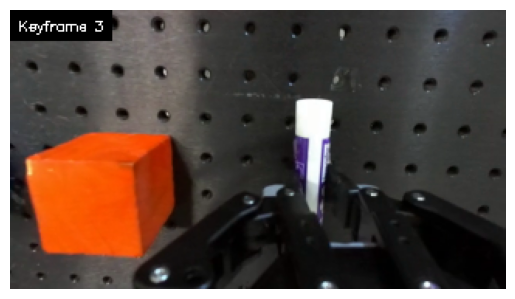

In [7]:
extracted_messages = process_single_file("/iris/u/jrpan/robo_memory/datasets/split_keyframes_subsample_5_augment_05_new_fs_prompt_new_golden_frames/2025-07-04__Fri_Jul__4_15_20_26_2025_keyframes/qa_data/qa_answer_500.json")

plt.imshow(extracted_messages['keyframe_3'])
plt.axis('off')
plt.show()

In [4]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing

base_dir = "/iris/u/jrpan/robo_memory/datasets/split_keyframes_subsample_5_augment_05_new_fs_prompt_new_golden_frames"
qa_answer_files = glob.glob(os.path.join(base_dir, "*/qa_data/qa_answer_*.json"))
print(f"Found {len(qa_answer_files)} qa_answer_*.json files")

max_workers = min(multiprocessing.cpu_count(), len(qa_answer_files))
all_extracted_data = []

with ProcessPoolExecutor(max_workers=80) as executor:
    futures = [executor.submit(process_single_file, json_file) for json_file in qa_answer_files]
    
    for future in tqdm(futures, desc="Processing files"):
        result = future.result()
        if result is not None:
            all_extracted_data.append(result)

df = pd.DataFrame(all_extracted_data)
print(f"Created DataFrame with {len(df)} rows")
df.head(5)

Found 24010 qa_answer_*.json files


Processing files: 100%|██████████| 24010/24010 [02:28<00:00, 161.35it/s]


Created DataFrame with 24010 rows


,prompt,recent_frame_1_path,recent_frame_2_path,recent_frame_3_path,recent_frame_4_path,recent_frame_5_path,recent_frame_6_path,keyframe_1_path,keyframe_2_path,subtask_target,recent_frame_1,recent_frame_2,recent_frame_3,recent_frame_4,recent_frame_5,recent_frame_6,keyframe_1,keyframe_2
0,You are looking through an egocentric camera a...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,look inside the black bin,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
1,You are looking through an egocentric camera a...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,NaN,NaN,NaN,look inside the white bin,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",NaN,NaN,NaN
2,You are looking through an egocentric camera a...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,pick up the eraser and put it in the white bin,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
3,You are looking through an egocentric camera a...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,pick up the red block and put it in the white bin,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...","[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
4,You are looking through an egocentric camera a...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_memory/datasets/split_keyfr...,/iris/u/jrpan/robo_mem

In [5]:
cols_to_save = [col for col in df.columns if not col.endswith('_path')]
df[cols_to_save].to_pickle("/iris/u/jrpan/openpi/subtask_prediction_df_16_frames_truncated.pkl")